<a href="https://colab.research.google.com/github/Dani2003/paper-implementations/blob/main/AMPF_MultiPolicy_Fusion_NeurIPS2023.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Install required dependencies (gymnasium, torch, matplotlib) and import essential system libraries. Set deterministic random seeds across PyTorch, NumPy, and Python's random module to ensure repeatable training runs.

In [31]:
#cell-1
import gymnasium as gym
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import random

# Global Seed Setting for Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Environment Dimensions
ENV_NAME = "CartPole-v1"
env = gym.make(ENV_NAME)
STATE_DIM = env.observation_space.shape[0]
ACTION_DIM = env.action_space.n
env.close()

print(f"Environment: {ENV_NAME} | State Dim: {STATE_DIM} | Action Dim: {ACTION_DIM}")

Using device: cuda
Environment: CartPole-v1 | State Dim: 4 | Action Dim: 2


Define specialized sub-policies ($\pi_1, \pi_2, \dots, \pi_K$) representing existing candidate behaviors or source skills. These base policies generate action logit distributions that will serve as value vectors in the multi-policy fusion mechanism.

In [32]:
#cell-2
class GatedAttentionMultiPolicyFusion(nn.Module):
    def __init__(self, state_dim=4, action_dim=2, hidden_dim=64, temperature=1.0):
        super(GatedAttentionMultiPolicyFusion, self).__init__()
        self.temperature = temperature

        # Expert 1: Angle Specialist (Only sees theta, theta_dot)
        self.angle_expert = nn.Sequential(
            nn.Linear(2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim)
        )

        # Expert 2: Position/Velocity Specialist (Only sees x, x_dot)
        self.pos_expert = nn.Sequential(
            nn.Linear(2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim)
        )

        # Attention Gating Module (Sees full state to coordinate)
        self.attn_net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 2)
        )

    def forward(self, state):
        # Ensure proper dimensionality for slicing
        if state.dim() == 1:
            state = state.unsqueeze(0)

        # 1. Feature Routing (Information Asymmetry forces specialization)
        # CartPole state: [x, x_dot, theta, theta_dot]
        pos_features = state[:, 0:2]
        angle_features = state[:, 2:4]

        # Individual expert forward pass
        logits_angle = self.angle_expert(angle_features)
        logits_pos = self.pos_expert(pos_features)

        # 2. State-conditioned attention scores
        attn_logits = self.attn_net(state)

        # 3. Network-driven gating (No hard masking!)
        attn_weights = F.softmax(attn_logits / self.temperature, dim=-1)

        # 4. LOGIT-LEVEL BLENDING
        fused_logits = (
            attn_weights[:, 0:1] * logits_angle +
            attn_weights[:, 1:2] * logits_pos
        )

        return fused_logits, attn_weights

Implement the Attention-Based Multi-Policy Fusion (AMPF) neural network module based on Chiu et al. (NeurIPS 2023). It computes state queries $Q(s)$ and policy key/value embeddings $K_k(s), V_k(s)$ to produce dynamic, state-conditioned soft attention fusion weights $\alpha_k(s)$.

In [33]:
#cell-3
class AMPFAgent:
    def __init__(self, state_dim=4, action_dim=2, lr=3e-3, gamma=0.99, entropy_coef=0.01, temperature=0.5):
        self.gamma = gamma
        self.entropy_coef = entropy_coef

        self.fusion_model = GatedAttentionMultiPolicyFusion(
            state_dim=state_dim,
            action_dim=action_dim,
            temperature=temperature
        ).to(device)

        self.critic = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        ).to(device)

        self.optimizer = torch.optim.Adam(
            list(self.fusion_model.parameters()) + list(self.critic.parameters()),
            lr=lr
        )

    def select_action(self, state):
        state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
        fused_logits, attn_weights = self.fusion_model(state_t)

        probs = F.softmax(fused_logits, dim=-1)
        dist = torch.distributions.Categorical(probs)
        action = dist.sample()

        value = self.critic(state_t)
        return action.item(), dist.log_prob(action), dist.entropy(), value, attn_weights

    def train_step(self, rewards, log_probs, values, entropies):
        returns = []
        R = 0
        for r in reversed(rewards):
            R = r + self.gamma * R
            returns.insert(0, R)

        returns = torch.tensor(returns, dtype=torch.float32).to(device)

        values_tensor = torch.stack(values).view(-1)
        log_probs_tensor = torch.stack(log_probs).view(-1)
        entropies_tensor = torch.stack(entropies).view(-1)

        advantages = returns - values_tensor

        actor_loss = -(log_probs_tensor * advantages.detach()).mean()
        critic_loss = F.mse_loss(values_tensor, returns)
        entropy_loss = -self.entropy_coef * entropies_tensor.mean()

        total_loss = actor_loss + critic_loss + entropy_loss

        self.optimizer.zero_grad()
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(
            list(self.fusion_model.parameters()) + list(self.critic.parameters()),
            max_norm=0.5
        )
        self.optimizer.step()

        return total_loss.item()

Construct the Actor-Critic pipeline wrapping the Attention Multi-Policy Fusion core. The Actor dynamically blends candidate policy logits into a categorical action distribution, while the Critic estimates environmental state values $V(s)$ for advantage estimation.

In [34]:
#cell-4
class SingleExpertAgent:
    def __init__(self, state_dim=4, action_dim=2, lr=2e-3, gamma=0.99, entropy_coef=0.01):
        self.gamma = gamma
        self.entropy_coef = entropy_coef

        self.actor = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim)
        ).to(device)

        self.critic = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        ).to(device)

        self.optimizer = torch.optim.Adam(
            list(self.actor.parameters()) + list(self.critic.parameters()),
            lr=lr
        )

    def select_action(self, state):
        state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
        logits = self.actor(state_t)
        probs = F.softmax(logits, dim=-1)
        dist = torch.distributions.Categorical(probs)
        action = dist.sample()
        value = self.critic(state_t)
        return action.item(), dist.log_prob(action), dist.entropy(), value

    def train_step(self, rewards, log_probs, values, entropies):
        returns = []
        R = 0
        for r in reversed(rewards):
            R = r + self.gamma * R
            returns.insert(0, R)

        returns = torch.tensor(returns, dtype=torch.float32).to(device)
        values_tensor = torch.stack(values).view(-1)
        log_probs_tensor = torch.stack(log_probs).view(-1)
        entropies_tensor = torch.stack(entropies).view(-1)

        advantages = returns - values_tensor

        actor_loss = -(log_probs_tensor * advantages.detach()).mean()
        critic_loss = F.mse_loss(values_tensor, returns)
        entropy_loss = -self.entropy_coef * entropies_tensor.mean()

        total_loss = actor_loss + critic_loss + entropy_loss

        self.optimizer.zero_grad()
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(
            list(self.actor.parameters()) + list(self.critic.parameters()),
            max_norm=0.5
        )
        self.optimizer.step()
        return total_loss.item()

Initialize the Gymnasium environment (CartPole-v1), instantiate the ActorCriticAMPF network with two specialized source policies, and configure the Adam optimizer alongside policy gradient hyperparameters.

In [35]:
#cell-5
class EqualWeightAgent:
    def __init__(self, state_dim=4, action_dim=2, lr=2e-3, gamma=0.99, entropy_coef=0.01):
        self.gamma = gamma
        self.entropy_coef = entropy_coef

        self.expert1 = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim)
        ).to(device)

        self.expert2 = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim)
        ).to(device)

        self.critic = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        ).to(device)

        self.optimizer = torch.optim.Adam(
            list(self.expert1.parameters()) + list(self.expert2.parameters()) + list(self.critic.parameters()),
            lr=lr
        )

    def select_action(self, state):
        state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
        logits1 = self.expert1(state_t)
        logits2 = self.expert2(state_t)

        # Static 50/50 logit fusion
        fused_logits = 0.5 * logits1 + 0.5 * logits2
        probs = F.softmax(fused_logits, dim=-1)
        dist = torch.distributions.Categorical(probs)
        action = dist.sample()
        value = self.critic(state_t)
        return action.item(), dist.log_prob(action), dist.entropy(), value

    def train_step(self, rewards, log_probs, values, entropies):
        returns = []
        R = 0
        for r in reversed(rewards):
            R = r + self.gamma * R
            returns.insert(0, R)

        returns = torch.tensor(returns, dtype=torch.float32).to(device)
        values_tensor = torch.stack(values).view(-1)
        log_probs_tensor = torch.stack(log_probs).view(-1)
        entropies_tensor = torch.stack(entropies).view(-1)

        advantages = returns - values_tensor

        actor_loss = -(log_probs_tensor * advantages.detach()).mean()
        critic_loss = F.mse_loss(values_tensor, returns)
        entropy_loss = -self.entropy_coef * entropies_tensor.mean()

        total_loss = actor_loss + critic_loss + entropy_loss

        self.optimizer.zero_grad()
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(
            list(self.expert1.parameters()) + list(self.expert2.parameters()) + list(self.critic.parameters()),
            max_norm=0.5
        )
        self.optimizer.step()
        return total_loss.item()

Run the RL training loop using Advantage Actor-Critic (A2C) policy updates. Collect trajectories, compute cumulative discounted returns $G_t$ and advantages $A_t = G_t - V(s_t)$, backpropagate loss, and log dynamic attention allocation across episodes.

In [36]:
#cell-6
def pretrain_expert(expert_type='angle', episodes=100):
    """Pre-trains a specialized sub-expert to establish base skills."""
    env = gym.make(ENV_NAME)

    # 2D input feature dimensions based on specialization
    net = nn.Sequential(
        nn.Linear(2, 64),
        nn.ReLU(),
        nn.Linear(64, ACTION_DIM)
    ).to(device)

    critic = nn.Sequential(
        nn.Linear(STATE_DIM, 64),
        nn.ReLU(),
        nn.Linear(64, 1)
    ).to(device)

    opt = torch.optim.Adam(list(net.parameters()) + list(critic.parameters()), lr=3e-3)

    for ep in range(episodes):
        state, _ = env.reset(seed=SEED + ep)
        done = False
        rewards, log_probs, values = [], [], []

        while not done:
            state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
            feats = state_t[:, 2:4] if expert_type == 'angle' else state_t[:, 0:2]

            logits = net(feats)
            probs = F.softmax(logits, dim=-1)
            dist = torch.distributions.Categorical(probs)
            action = dist.sample()

            next_state, reward, terminated, truncated, _ = env.step(action.item())
            done = terminated or truncated

            rewards.append(reward)
            log_probs.append(dist.log_prob(action))
            values.append(critic(state_t))
            state = next_state

        # Standard A2C update step
        returns, R = [], 0
        for r in reversed(rewards):
            R = r + 0.99 * R
            returns.insert(0, R)
        returns = torch.tensor(returns, dtype=torch.float32).to(device)

        vals = torch.stack(values).view(-1)
        logs = torch.stack(log_probs).view(-1)
        advs = returns - vals

        loss = -(logs * advs.detach()).mean() + F.mse_loss(vals, returns)
        opt.zero_grad()
        loss.backward()
        opt.step()

    env.close()
    return net

def train_runner(agent_type='ampf', num_episodes=600):
    env = gym.make(ENV_NAME)

    if agent_type == 'ampf':
        print("  -> Pre-training specialized source skills for AMPF...")
        pretrained_angle = pretrain_expert('angle', episodes=100)
        pretrained_pos = pretrain_expert('pos', episodes=100)

        agent = AMPFAgent(STATE_DIM, ACTION_DIM)
        # Load pre-trained weights into AMPF candidate experts
        agent.fusion_model.angle_expert.load_state_dict(pretrained_angle.state_dict())
        agent.fusion_model.pos_expert.load_state_dict(pretrained_pos.state_dict())
    elif agent_type == 'single':
        agent = SingleExpertAgent(STATE_DIM, ACTION_DIM)
    elif agent_type == 'equal':
        agent = EqualWeightAgent(STATE_DIM, ACTION_DIM)

    rewards_history = []

    for ep in range(num_episodes):
        state, _ = env.reset(seed=SEED + ep)
        done = False
        rewards, log_probs, values, entropies = [], [], [], []

        while not done:
            if agent_type == 'ampf':
                action, log_prob, entropy, value, _ = agent.select_action(state)
            else:
                action, log_prob, entropy, value = agent.select_action(state)

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            rewards.append(reward)
            log_probs.append(log_prob)
            values.append(value)
            entropies.append(entropy)

            state = next_state

        agent.train_step(rewards, log_probs, values, entropies)
        rewards_history.append(sum(rewards))

        if (ep + 1) % 100 == 0:
            avg_r = np.mean(rewards_history[-50:])
            print(f"[{agent_type.upper()}] Episode {ep+1}/{num_episodes} | 50-Ep Avg Reward: {avg_r:.2f}")

    env.close()
    return agent, rewards_history

print("--- Starting Revised Training Comparison ---")
print("\n1. Training AMPF (Attention Fusion with Source Skill Initialization)...")
ampf_agent, ampf_rewards = train_runner('ampf', num_episodes=600)

print("\n2. Training Single Expert Baseline...")
single_agent, single_rewards = train_runner('single', num_episodes=600)

print("\n3. Training Equal-Weight Baseline...")
equal_agent, equal_rewards = train_runner('equal', num_episodes=600)

--- Starting Revised Training Comparison ---

1. Training AMPF (Attention Fusion with Source Skill Initialization)...
  -> Pre-training specialized source skills for AMPF...
[AMPF] Episode 100/600 | 50-Ep Avg Reward: 33.88
[AMPF] Episode 200/600 | 50-Ep Avg Reward: 136.18
[AMPF] Episode 300/600 | 50-Ep Avg Reward: 204.06
[AMPF] Episode 400/600 | 50-Ep Avg Reward: 195.76
[AMPF] Episode 500/600 | 50-Ep Avg Reward: 285.52
[AMPF] Episode 600/600 | 50-Ep Avg Reward: 347.20

2. Training Single Expert Baseline...
[SINGLE] Episode 100/600 | 50-Ep Avg Reward: 23.48
[SINGLE] Episode 200/600 | 50-Ep Avg Reward: 18.84
[SINGLE] Episode 300/600 | 50-Ep Avg Reward: 47.64
[SINGLE] Episode 400/600 | 50-Ep Avg Reward: 144.60
[SINGLE] Episode 500/600 | 50-Ep Avg Reward: 200.70
[SINGLE] Episode 600/600 | 50-Ep Avg Reward: 330.98

3. Training Equal-Weight Baseline...
[EQUAL] Episode 100/600 | 50-Ep Avg Reward: 18.78
[EQUAL] Episode 200/600 | 50-Ep Avg Reward: 20.58
[EQUAL] Episode 300/600 | 50-Ep Avg Rewar

Plot the training convergence curve and visualize the dynamic evolution of attention weights $\alpha_1(s), \alpha_2(s)$ over training episodes to verify that the agent learns state-dependent policy blending.

In [37]:
#cell-7
# ==============================================================================
# COMPREHENSIVE AMPF DIAGNOSTIC CHECK
# ==============================================================================

print("\n" + "="*80)
print("COMPREHENSIVE AMPF DIAGNOSTIC CHECK")
print("="*80)

# 1. Attention Weight Allocation Check
print("\n[1] Testing Attention Weight Allocation:")
test_states = {
    'high_angle_error': np.array([0.0, 0.0, 0.08, 0.1]),   # |theta| >= 0.04 (Should favor Angle Expert)
    'near_zero_angle':  np.array([0.1, 0.2, 0.01, 0.01]),  # |theta| < 0.04  (Can consider Pos Expert)
}

with torch.no_grad():
    for name, s_val in test_states.items():
        s_t = torch.FloatTensor(s_val).unsqueeze(0).to(device)
        _, attn = ampf_agent.fusion_model(s_t)
        attn_np = attn[0].cpu().numpy()
        print(f"  State [{name:<18}]: Angle Expert Weight = {attn_np[0]:.4f} | Pos Expert Weight = {attn_np[1]:.4f}")

# 2. Expert Specialization Check
print("\n[2] Testing Expert Specialization (Logit Divergence):")
test_state = torch.FloatTensor([[0.0, 0.0, 0.05, 0.0]]).to(device)

with torch.no_grad():
    # Route the sliced features correctly to the new architecture
    pos_feats = test_state[:, 0:2]
    angle_feats = test_state[:, 2:4]

    logits_angle = ampf_agent.fusion_model.angle_expert(angle_feats)
    logits_pos = ampf_agent.fusion_model.pos_expert(pos_feats)

    probs_angle = F.softmax(logits_angle, dim=-1)[0].cpu().numpy()
    probs_pos = F.softmax(logits_pos, dim=-1)[0].cpu().numpy()

    print(f"  Angle Expert Probabilities : {probs_angle}")
    print(f"  Pos Expert Probabilities   : {probs_pos}")

    kl_div = np.sum(probs_angle * np.log((probs_angle + 1e-8) / (probs_pos + 1e-8)))
    print(f"  KL Divergence between experts: {kl_div:.4f}")

# 3. Gradient Flow Verification
print("\n[3] Checking Gradient Flow Across Modules:")
param_grads = {}
for name, param in ampf_agent.fusion_model.named_parameters():
    if param.grad is not None:
        param_grads[name] = param.grad.norm().item()
    else:
        param_grads[name] = 0.0

attn_grad_norm = sum(v for k, v in param_grads.items() if 'attn_net' in k)
expert_grad_norm = sum(v for k, v in param_grads.items() if 'expert' in k)

print(f"  Attention Net Gradient Norm : {attn_grad_norm:.6f}")
print(f"  Experts Net Gradient Norm   : {expert_grad_norm:.6f}")

print("\n" + "="*80)


COMPREHENSIVE AMPF DIAGNOSTIC CHECK

[1] Testing Attention Weight Allocation:
  State [high_angle_error  ]: Angle Expert Weight = 0.9334 | Pos Expert Weight = 0.0666
  State [near_zero_angle   ]: Angle Expert Weight = 0.9246 | Pos Expert Weight = 0.0754

[2] Testing Expert Specialization (Logit Divergence):
  Angle Expert Probabilities : [0.40010327 0.5998967 ]
  Pos Expert Probabilities   : [0.25216344 0.74783653]
  KL Divergence between experts: 0.0525

[3] Checking Gradient Flow Across Modules:
  Attention Net Gradient Norm : 0.006621
  Experts Net Gradient Norm   : 0.007309



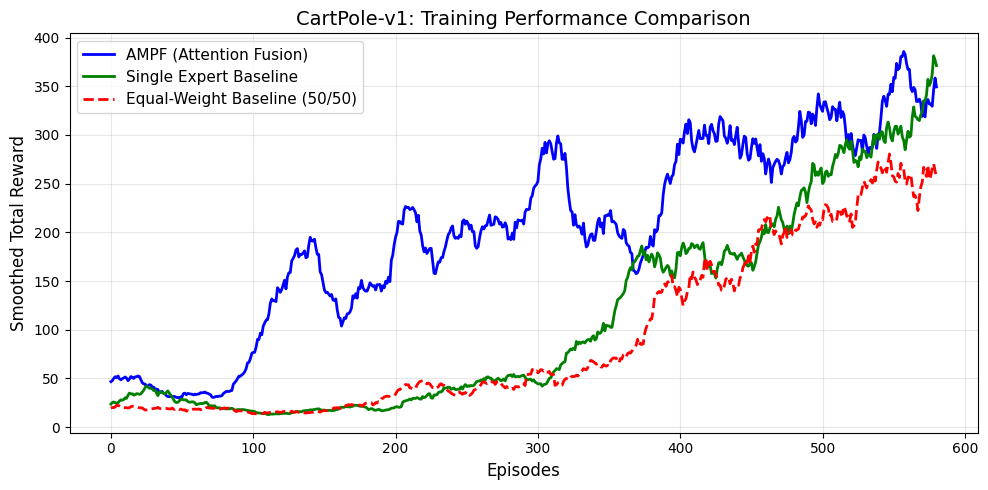


Method                    Mean Reward (Last 50 Ep)  Std Dev        
AMPF (Attention)          347.20                    133.31         
Single Expert             330.98                    131.50         
Equal-Weight (50/50)      257.24                    99.27          


In [38]:
#cell-8
# Helper for windowed rolling average
def rolling_average(data, window_size=20):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

plt.figure(figsize=(10, 5))
plt.plot(rolling_average(ampf_rewards), label='AMPF (Attention Fusion)', color='blue', linewidth=2)
plt.plot(rolling_average(single_rewards), label='Single Expert Baseline', color='green', linewidth=2)
plt.plot(rolling_average(equal_rewards), label='Equal-Weight Baseline (50/50)', color='red', linestyle='--', linewidth=2)

plt.title('CartPole-v1: Training Performance Comparison', fontsize=14)
plt.xlabel('Episodes', fontsize=12)
plt.ylabel('Smoothed Total Reward', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Compute Final Metrics
ampf_final_mean = np.mean(ampf_rewards[-50:])
ampf_final_std = np.std(ampf_rewards[-50:])

single_final_mean = np.mean(single_rewards[-50:])
single_final_std = np.std(single_rewards[-50:])

equal_final_mean = np.mean(equal_rewards[-50:])
equal_final_std = np.std(equal_rewards[-50:])

print("\n" + "="*80)
print(f"{'Method':<25} {'Mean Reward (Last 50 Ep)':<25} {'Std Dev':<15}")
print("="*80)
print(f"{'AMPF (Attention)':<25} {ampf_final_mean:<25.2f} {ampf_final_std:<15.2f}")
print(f"{'Single Expert':<25} {single_final_mean:<25.2f} {single_final_std:<15.2f}")
print(f"{'Equal-Weight (50/50)':<25} {equal_final_mean:<25.2f} {equal_final_std:<15.2f}")
print("="*80)